In [2]:
import os, json

EXPERIMENT_NAME = "cnn_transformer_v1"
SAVE_DIR = f"experiments/{EXPERIMENT_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)

CONFIG = {
    "model": "CNNTransformer",
    "seq_len": 32,
    "batch_size": 8,
    "epochs": 50,
    "lr": 1e-4,
    "dropout": 0.3
}

with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)

print("✅ Experiment folder created:", SAVE_DIR)


✅ Experiment folder created: experiments/cnn_transformer_v1


In [3]:
import numpy as np

train_seq_paths  = np.load("train_seq_paths.npy", allow_pickle=True)
train_seq_feats  = np.load("train_seq_feats.npy")
train_seq_labels = np.load("train_seq_labels.npy")

val_seq_paths  = np.load("val_seq_paths.npy", allow_pickle=True)
val_seq_feats  = np.load("val_seq_feats.npy")
val_seq_labels = np.load("val_seq_labels.npy")

test_seq_paths  = np.load("test_seq_paths.npy", allow_pickle=True)
test_seq_feats  = np.load("test_seq_feats.npy")
test_seq_labels = np.load("test_seq_labels.npy")

print("✅ Sequences loaded successfully!")


✅ Sequences loaded successfully!


Modele without Enycraption

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2
from PIL import Image
import numpy as np
import gc
from torch.optim.lr_scheduler import ReduceLROnPlateau

torch.cuda.empty_cache()
gc.collect()


15

In [5]:
train_tf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [6]:
class SeqDataset(Dataset):
    def __init__(self, seq_paths, seq_feats, seq_labels, transform):
        self.seq_paths = seq_paths
        self.seq_feats = seq_feats
        self.seq_labels = seq_labels
        self.tf = transform
        
    def __len__(self):
        return len(self.seq_paths)
    
    def load_img(self, p):
        try:
            img = Image.open(p).convert("RGB")
            return self.tf(img)
        except:
            return torch.zeros((3, 160, 160))
    
    def __getitem__(self, idx):
        imgs = torch.stack([self.load_img(p) for p in self.seq_paths[idx]])
        feats = torch.tensor(self.seq_feats[idx], dtype=torch.float32)
        label = torch.tensor(self.seq_labels[idx], dtype=torch.long)
        return imgs, feats, label


In [7]:
class CNNTransformer(nn.Module):
    def __init__(self, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()

        m = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = m.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.d_model = 512 + extra_dim

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B * T, C, H, W)

        x = self.cnn(x)
        x = self.pool(x).view(B, T, 1280)
        x = self.reduce(x)

        x = torch.cat([x, feats], dim=2)
        x = self.transformer(x)

        x = x.mean(dim=1) + x.max(dim=1)[0]
        return self.fc(x)


In [8]:
train_seq_paths = np.load("train_seq_paths.npy", allow_pickle=True)
train_seq_feats = np.load("train_seq_feats.npy")
train_seq_labels = np.load("train_seq_labels.npy")

val_seq_paths = np.load("val_seq_paths.npy", allow_pickle=True)
val_seq_feats = np.load("val_seq_feats.npy")
val_seq_labels = np.load("val_seq_labels.npy")

test_seq_paths = np.load("test_seq_paths.npy", allow_pickle=True)
test_seq_feats = np.load("test_seq_feats.npy")
test_seq_labels = np.load("test_seq_labels.npy")

print("✅ Sequences loaded")


✅ Sequences loaded


In [9]:
train_ds = SeqDataset(train_seq_paths, train_seq_feats, train_seq_labels, train_tf)
val_ds   = SeqDataset(val_seq_paths, val_seq_feats, val_seq_labels, val_tf)
test_ds  = SeqDataset(test_seq_paths, test_seq_feats, test_seq_labels, val_tf)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=4)

print("✓ DataLoaders Ready!")


✓ DataLoaders Ready!


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNNTransformer().to(device)

labels_np = np.array(train_seq_labels)
class_counts = np.bincount(labels_np)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=3)

scaler = torch.cuda.amp.GradScaler()


In [18]:
EPOCHS = 50
BEST_MODEL_PATH = f"{SAVE_DIR}/best_model.pth"

best_val_acc = 0.0
patience = 10
wait = 0

train_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("\n🚀 Starting Training...\n")

for epoch in range(1, EPOCHS + 1):

    # TRAIN
   
    model.train()
    train_loss = 0.0
    train_correct = 0
    total = 0

    for imgs, feats, labels in train_loader:
        imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs, feats)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    train_acc = train_correct / total
    train_loss /= total

    # VALIDATION
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, feats, labels in val_loader:
            imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(imgs, feats)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += imgs.size(0)

    val_acc = val_correct / val_total
    val_loss /= val_total

    # Save history
    train_history["train_loss"].append(train_loss)
    train_history["train_acc"].append(train_acc)
    train_history["val_loss"].append(val_loss)
    train_history["val_acc"].append(val_acc)

    scheduler.step(val_acc)

    print(
        f"Epoch [{epoch}/{EPOCHS}] | "
        f"Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f}"
    )

    ##############################
    # EARLY STOPPING
    ##############################
    if val_acc > best_val_acc:
        print("🏆 New best model saved!")
        best_val_acc = val_acc
        wait = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "train_history": train_history
        }, BEST_MODEL_PATH)

    else:
        wait += 1
        print(f"⏳ No improvement ({wait}/{patience})")

        if wait >= patience:
            print("🛑 Early stopping triggered!")
            break

    print("-" * 80)

print("\n✅ Training Finished!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")



🚀 Starting Training...

Epoch [1/50] | Train Acc: 0.9010, Loss: 0.6776 | Val Acc: 0.9612, Loss: 0.7777
🏆 New best model saved!
--------------------------------------------------------------------------------
Epoch [2/50] | Train Acc: 0.9505, Loss: 0.6083 | Val Acc: 0.9338, Loss: 0.8148
⏳ No improvement (1/10)
--------------------------------------------------------------------------------
Epoch [3/50] | Train Acc: 0.9626, Loss: 0.5862 | Val Acc: 0.9726, Loss: 0.7451
🏆 New best model saved!
--------------------------------------------------------------------------------
Epoch [4/50] | Train Acc: 0.9656, Loss: 0.5900 | Val Acc: 0.9537, Loss: 0.7971
⏳ No improvement (1/10)
--------------------------------------------------------------------------------
Epoch [5/50] | Train Acc: 0.9734, Loss: 0.5676 | Val Acc: 0.9764, Loss: 0.7671
🏆 New best model saved!
--------------------------------------------------------------------------------
Epoch [6/50] | Train Acc: 0.9700, Loss: 0.5772 | Val Ac

In [27]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint = torch.load(
    "./experiments/cnn_transformer_v1/best_model.pth",
    map_location=device
)

model = CNNTransformer().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import torch
import torch.nn.functional as F


In [29]:
import torch

def evaluate_test_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, feats, labels in dataloader:
            imgs   = imgs.to(device)
            feats  = feats.to(device)
            labels = labels.to(device)

            outputs = model(imgs, feats)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return correct / total


In [30]:
test_acc = evaluate_test_accuracy(model, test_loader, device)

print(f"🎯 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


🎯 Test Accuracy: 0.9762 (97.62%)


In [32]:
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs   = imgs.to(device)
        feats  = feats.to(device)
        labels = labels.to(device)

        outputs = model(imgs, feats)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [33]:
class_names = ["alert", "microsleep", "yawning"]

print("📊 Classification Report (Test Set):\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)


📊 Classification Report (Test Set):

              precision    recall  f1-score   support

       alert     0.9916    0.9775    0.9845       844
  microsleep     0.9029    0.9693    0.9349       163
     yawning     0.9770    0.9770    0.9770        87

    accuracy                         0.9762      1094
   macro avg     0.9572    0.9746    0.9655      1094
weighted avg     0.9772    0.9762    0.9765      1094



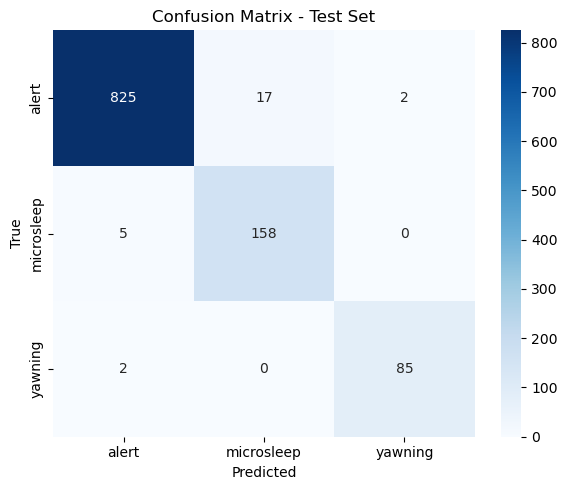

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()


In [39]:
import torch
import torch.nn.functional as F
import numpy as np

model.eval()

all_labels = []
all_preds  = []
all_probs  = []

test_loss = 0.0
total = 0

criterion = torch.nn.CrossEntropyLoss()

with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs   = imgs.to(device)
        feats  = feats.to(device)
        labels = labels.to(device)

        outputs = model(imgs, feats)
        loss = criterion(outputs, labels)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        test_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_loss /= total
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

print(f"🎯 Test Accuracy : {test_acc:.4f}")
print(f"📉 Test Loss     : {test_loss:.4f}")


🎯 Test Accuracy : 0.9762
📉 Test Loss     : 0.2836


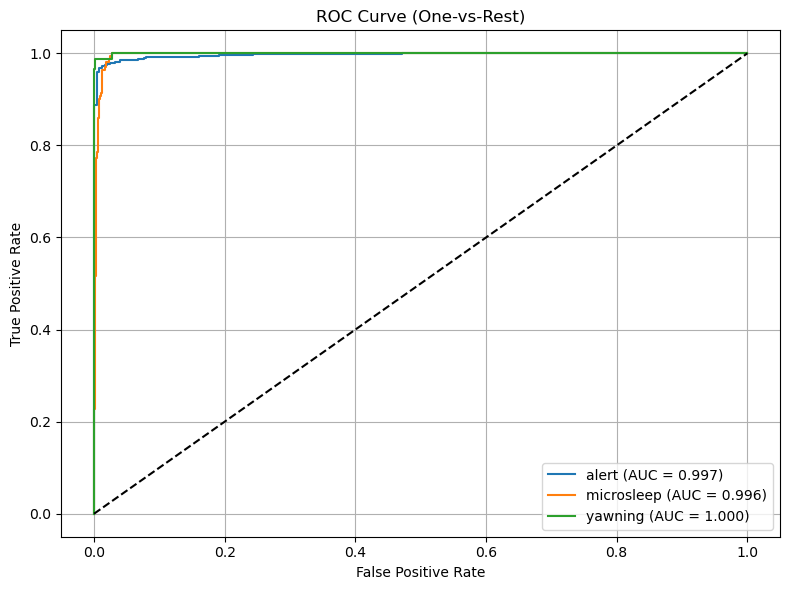

In [41]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# One-hot encoding
labels_onehot = label_binarize(all_labels, classes=[0,1,2])

plt.figure(figsize=(8,6))
auc_scores = {}

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
    auc_score = auc(fpr, tpr)
    auc_scores[cls] = auc_score

    plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
macro_auc = np.mean(list(auc_scores.values()))

print("\n🧮 AUC Scores:")
for k, v in auc_scores.items():
    print(f"{k:12s}: {v:.4f}")

print(f"\n⭐ Macro AUC : {macro_auc:.4f}")



🧮 AUC Scores:
alert       : 0.9968
microsleep  : 0.9963
yawning     : 0.9996

⭐ Macro AUC : 0.9976


In [45]:
import time
import numpy as np

model.eval()
latencies = []

with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs = imgs.to(device)
        feats = feats.to(device)

        torch.cuda.synchronize()  # مهم للـ GPU
        start = time.time()

        _ = model(imgs, feats)

        torch.cuda.synchronize()
        end = time.time()

        latencies.append((end - start) * 1000)  # ms

latencies = np.array(latencies)

print("⏱️ Latency Metrics:")
print(f"Mean Latency   : {latencies.mean():.2f} ms")
print(f"Median Latency : {np.median(latencies):.2f} ms")
print(f"Std Latency    : {latencies.std():.2f} ms")


⏱️ Latency Metrics:
Mean Latency   : 120.40 ms
Median Latency : 121.16 ms
Std Latency    : 3.32 ms


In [46]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("🧮 Model Size:")
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")


🧮 Model Size:
Total Parameters     : 9,395,247
Trainable Parameters : 9,395,247


In [48]:
model.eval()
total_samples = 0
total_time = 0.0

with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs = imgs.to(device)
        feats = feats.to(device)

        batch_size = imgs.size(0)
        torch.cuda.synchronize()
        start = time.time()

        _ = model(imgs, feats)

        torch.cuda.synchronize()
        end = time.time()

        total_samples += batch_size
        total_time += (end - start)

throughput = total_samples / total_time

print("🚀 Throughput:")
print(f"{throughput:.2f} samples/sec")


🚀 Throughput:
65.89 samples/sec


In [11]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from io import BytesIO

from torch.optim.lr_scheduler import ReduceLROnPlateau
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

torch.cuda.empty_cache()
gc.collect()

print("✅ Imports loaded & memory cleaned")


✅ Imports loaded & memory cleaned


In [12]:
# 🔑 AES key path (correct & explicit)
KEY_PATH = "/home/jovyan/myenvs/Driver Drowsiness Detection/aes_key.bin"

with open(KEY_PATH, "rb") as f:
    AES_KEY = f.read()

print(f"✅ AES key loaded successfully ({len(AES_KEY)} bytes)")


✅ AES key loaded successfully (32 bytes)


In [13]:
def aes_decrypt_bytes(encrypted_data: bytes, key: bytes) -> bytes:
    """
    AES-256-GCM decryption
    Format: nonce (12 bytes) | ciphertext+tag
    """
    nonce = encrypted_data[:12]
    ciphertext = encrypted_data[12:]

    aesgcm = AESGCM(key)
    plaintext = aesgcm.decrypt(nonce, ciphertext, None)
    return plaintext

print("✅ AES decryption function ready")


✅ AES decryption function ready


In [14]:
train_tf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms ready")


✅ Transforms ready


In [15]:
def to_encrypted_path(p):
    """
    Convert plain image path to encrypted image path (.jpg.bin)
    """
    return (
        p.replace(
            "/home/jovyan/myenvs/FBF/classification_frames",
            "/home/jovyan/myenvs/FBF/encrypted_images_aes"
        ) + ".bin"
    )

# 🔄 Convert ALL paths
train_seq_paths = [[to_encrypted_path(p) for p in seq] for seq in train_seq_paths]
val_seq_paths   = [[to_encrypted_path(p) for p in seq] for seq in val_seq_paths]
test_seq_paths  = [[to_encrypted_path(p) for p in seq] for seq in test_seq_paths]

print("✅ All sequence paths converted to encrypted paths")
print("🔍 Example:", train_seq_paths[0][0])


✅ All sequence paths converted to encrypted paths
🔍 Example: /home/jovyan/myenvs/FBF/encrypted_images_aes/P1042756_720/frame0.jpg.bin


In [16]:
from torch.utils.data import Dataset
from PIL import Image
from io import BytesIO
import torch

class EncryptedSeqDataset(Dataset):
    def __init__(self, seq_paths, seq_feats, seq_labels, transform, aes_key):
        self.seq_paths = seq_paths
        self.seq_feats = seq_feats
        self.seq_labels = seq_labels
        self.tf = transform
        self.aes_key = aes_key

    def __len__(self):
        return len(self.seq_paths)

    def load_encrypted_img(self, path):
        try:
            with open(path, "rb") as f:
                encrypted_data = f.read()

            decrypted = aes_decrypt_bytes(encrypted_data, self.aes_key)
            img = Image.open(BytesIO(decrypted)).convert("RGB")
            return self.tf(img)

        except Exception as e:
            print(f"⚠️ Decryption failed: {path}")
            return torch.zeros((3, 160, 160))

    def __getitem__(self, idx):
        imgs = torch.stack([self.load_encrypted_img(p) for p in self.seq_paths[idx]])
        feats = torch.tensor(self.seq_feats[idx], dtype=torch.float32)
        label = torch.tensor(self.seq_labels[idx], dtype=torch.long)
        return imgs, feats, label

print("✅ EncryptedSeqDataset ready")


✅ EncryptedSeqDataset ready


In [17]:
class CNNTransformer(nn.Module):
    def __init__(self, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()

        backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.d_model = 512 + extra_dim

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B*T, C, H, W)

        x = self.cnn(x)
        x = self.pool(x)
        x = x.view(B, T, 1280)

        x = self.reduce(x)
        x = torch.cat([x, feats], dim=2)

        x = self.transformer(x)

        x = x.mean(dim=1) + x.max(dim=1)[0]
        return self.fc(x)

print("✅ Model defined")


✅ Model defined


In [18]:
from torch.utils.data import DataLoader

train_ds = EncryptedSeqDataset(
    train_seq_paths, train_seq_feats, train_seq_labels, train_tf, AES_KEY
)

val_ds = EncryptedSeqDataset(
    val_seq_paths, val_seq_feats, val_seq_labels, val_tf, AES_KEY
)

test_ds = EncryptedSeqDataset(
    test_seq_paths, test_seq_feats, test_seq_labels, val_tf, AES_KEY
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=4)

print("✅ Encrypted DataLoaders created successfully")


✅ Encrypted DataLoaders created successfully


In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNNTransformer().to(device)

labels_np = np.array(train_seq_labels)
class_weights = 1.0 / np.bincount(labels_np)
class_weights = torch.tensor(
    class_weights / class_weights.sum() * len(class_weights),
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=3)

scaler = torch.cuda.amp.GradScaler()

print("✅ Training setup ready")


✅ Training setup ready


In [16]:
EPOCHS = 50
BEST_MODEL_PATH = "best_cnn_transformer_encrypted.pth"

best_val_acc = 0.0
patience = 10
wait = 0

train_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("\n🚀 Starting CLEAN training with encrypted data...\n")

for epoch in range(1, EPOCHS + 1):

    # =================================================
    # TRAIN
    # =================================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    total = 0

    for imgs, feats, labels in train_loader:
        imgs = imgs.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            outputs = model(imgs, feats)
            loss = criterion(outputs, labels)

        # Backward (AMP)
        scaler.scale(loss).backward()

        # ✅ unscale مرة واحدة فقط
        scaler.unscale_(optimizer)

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Optimizer step
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    train_loss /= total
    train_acc = train_correct / total

    # =================================================
    # VALIDATION
    # =================================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, feats, labels in val_loader:
            imgs = imgs.to(device)
            feats = feats.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(imgs, feats)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += imgs.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # =================================================
    # SAVE HISTORY
    # =================================================
    train_history["train_loss"].append(train_loss)
    train_history["train_acc"].append(train_acc)
    train_history["val_loss"].append(val_loss)
    train_history["val_acc"].append(val_acc)

    # =================================================
    # LR Scheduler
    # =================================================
    scheduler.step(val_acc)

    # =================================================
    # LOG
    # =================================================
    print(
        f"Epoch [{epoch}/{EPOCHS}] | "
        f"Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f}"
    )

    # =================================================
    # EARLY STOPPING + SAVE BEST MODEL
    # =================================================
    if val_acc > best_val_acc:
        print("🏆 New best model saved!")
        best_val_acc = val_acc
        wait = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
            "train_history": train_history
        }, BEST_MODEL_PATH)

    else:
        wait += 1
        print(f"⏳ No improvement ({wait}/{patience})")

        if wait >= patience:
            print("🛑 Early stopping triggered!")
            break

    print("-" * 80)

print("\n🔥 Training completed successfully!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")
print(f"💾 Model saved at: {BEST_MODEL_PATH}")



🚀 Starting CLEAN training with encrypted data...

Epoch [1/50] | Train Acc: 0.8895, Loss: 0.7058 | Val Acc: 0.9707, Loss: 0.7646
🏆 New best model saved!
--------------------------------------------------------------------------------
Epoch [2/50] | Train Acc: 0.9560, Loss: 0.6037 | Val Acc: 0.9225, Loss: 0.9510
⏳ No improvement (1/10)
--------------------------------------------------------------------------------
Epoch [3/50] | Train Acc: 0.9652, Loss: 0.5768 | Val Acc: 0.9367, Loss: 0.8389
⏳ No improvement (2/10)
--------------------------------------------------------------------------------
Epoch [4/50] | Train Acc: 0.9631, Loss: 0.5917 | Val Acc: 0.9575, Loss: 0.7746
⏳ No improvement (3/10)
--------------------------------------------------------------------------------
Epoch [5/50] | Train Acc: 0.9681, Loss: 0.5789 | Val Acc: 0.9764, Loss: 0.7604
🏆 New best model saved!
--------------------------------------------------------------------------------
Epoch [6/50] | Train Acc: 0.9

In [13]:
class CNNTransformer(nn.Module):
    def __init__(self, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3, pooling_type="hybrid"):
        super().__init__()
        self.pooling_type = pooling_type  # "hybrid" or "average"
        
        backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.d_model = 512 + extra_dim
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B*T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x).view(B, T, 1280)
        x = self.reduce(x)
        x = torch.cat([x, feats], dim=2)
        x = self.transformer(x)
        
        # التجميع الزمني (المفتاح هنا!)
        if self.pooling_type == "average":
            x = x.mean(dim=1)  # ← Average Pooling فقط
        elif self.pooling_type == "hybrid":
            x = x.mean(dim=1) + x.max(dim=1)[0]  # ← Mean + Max
        
        return self.fc(x)

In [14]:
# تحميل النموذج المدرب
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("best_cnn_transformer_encrypted.pth", map_location=device)

# النموذج مع Average Pooling
model_avg = CNNTransformer(pooling_type="average").to(device)
model_avg.load_state_dict(checkpoint["model_state_dict"])
model_avg.eval()

# النموذج مع Hybrid Pooling
model_hybrid = CNNTransformer(pooling_type="hybrid").to(device)
model_hybrid.load_state_dict(checkpoint["model_state_dict"])
model_hybrid.eval()

from sklearn.metrics import f1_score, accuracy_score

# تقييم Average Pooling
preds_avg, labels_true = [], []
with torch.no_grad():
    for imgs, feats, labels in test_loader:
        outputs = model_avg(imgs.to(device), feats.to(device))
        preds_avg.extend(outputs.argmax(1).cpu().numpy())
        labels_true.extend(labels.numpy())

acc_avg = accuracy_score(labels_true, preds_avg)
f1_avg = f1_score(labels_true, preds_avg, average='macro')

# تقييم Hybrid Pooling
preds_hybrid, labels_true2 = [], []
with torch.no_grad():
    for imgs, feats, labels in test_loader:
        outputs = model_hybrid(imgs.to(device), feats.to(device))
        preds_hybrid.extend(outputs.argmax(1).cpu().numpy())
        labels_true2.extend(labels.numpy())

acc_hybrid = accuracy_score(labels_true2, preds_hybrid)
f1_hybrid = f1_score(labels_true2, preds_hybrid, average='macro')

# عرض النتائج
print("="*60)
print("📊 RESULTS: AVERAGE vs HYBRID POOLING")
print("="*60)
print(f"Metric          | Average Pooling | Hybrid Pooling | Improvement")
print("-"*60)
print(f"Accuracy        | {acc_avg:.4f}       | {acc_hybrid:.4f}    | {acc_hybrid - acc_avg:+.4f}")
print(f"Macro-F1        | {f1_avg:.4f}       | {f1_hybrid:.4f}    | {f1_hybrid - f1_avg:+.4f}")
print("="*60)

📊 RESULTS: AVERAGE vs HYBRID POOLING
Metric          | Average Pooling | Hybrid Pooling | Improvement
------------------------------------------------------------
Accuracy        | 0.9744       | 0.9753    | +0.0009
Macro-F1        | 0.9582       | 0.9602    | +0.0019


In [33]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# المسار الصحيح الذي وجدته
model_path = "/home/jovyan/final /experiments/best_cnn_transformer_encrypted (3).pth"

# تحقق من وجوده (للتأكد)
assert os.path.exists(model_path), f"الملف غير موجود: {model_path}"

# تحميل النموذج
checkpoint_enc = torch.load(model_path, map_location=device)

# تحميل الوزنات
encrypted_model = CNNTransformer().to(device)
encrypted_model.load_state_dict(checkpoint_enc["model_state_dict"])
encrypted_model.eval()

print("✅ النموذج تم تحميله بنجاح!")

✅ النموذج تم تحميله بنجاح!


In [25]:
class CNNTransformerMixed(nn.Module):
    def __init__(self, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()
        # نفس البنية تمامًا
        backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.d_model = 512 + extra_dim
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats, alpha=0.5):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B*T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x).view(B, T, 1280)
        x = self.reduce(x)
        x = torch.cat([x, feats], dim=2)
        x = self.transformer(x)
        
        # Mixed Pooling (Lee et al., 2016)
        mean_pool = x.mean(dim=1)
        max_pool = x.max(dim=1)[0]
        x = alpha * mean_pool + (1 - alpha) * max_pool
        
        return self.fc(x)

In [38]:
import torch
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------
# 1. تقييم نموذجك الأصلي (Hybrid)
# ----------------------------
model_hybrid = CNNTransformer(pooling_type="hybrid").to(device)
model_hybrid.load_state_dict(checkpoint_enc["model_state_dict"])
model_hybrid.eval()

preds_hybrid, labels_true = [], []
with torch.no_grad():
    for imgs, feats, labels in test_loader:
        outputs = model_hybrid(imgs.to(device), feats.to(device))
        preds_hybrid.extend(outputs.argmax(1).cpu().numpy())
        labels_true.extend(labels.numpy())

acc_hybrid = accuracy_score(labels_true, preds_hybrid)
f1_hybrid = f1_score(labels_true, preds_hybrid, average='macro')

# ----------------------------
# 2. تقييم Mixed Pooling (Lee et al., 2016)
# ----------------------------
def evaluate_mixed(alpha):
    model_mixed = CNNTransformerMixed().to(device)
    model_mixed.load_state_dict(checkpoint_enc["model_state_dict"])
    model_mixed.eval()
    
    preds, labels = [], []
    with torch.no_grad():
        for imgs, feats, lbls in test_loader:
            outputs = model_mixed(imgs.to(device), feats.to(device), alpha=alpha)
            preds.extend(outputs.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return acc, f1

# جرّب قيم مختلفة لـ α
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
results = {}
for a in alphas:
    acc, f1 = evaluate_mixed(a)
    results[a] = (acc, f1)

# ----------------------------
# 3. عرض النتائج
# ----------------------------
print("="*70)
print("📊 COMPARISON: OUR HYBRID vs LEE ET AL. (2016) MIXED POOLING")
print("="*70)
print(f"Method                                | Accuracy | Macro-F1")
print("-"*70)
print(f"Ours: Mean + Max (additive)           | {acc_hybrid:.4f}   | {f1_hybrid:.4f}")
print("-"*70)
for a in alphas:
    acc, f1 = results[a]
    marker = " ← identical to ours" if a == 0.5 else ""
    print(f"Mixed Pooling (α = {a:4.2f})                | {acc:.4f}   | {f1:.4f}{marker}")
print("="*70)

# ----------------------------
# 4. تفسير النتيجة (اختياري)
# ----------------------------
print("\n💡 Explanation:")
print("- When α = 0.5, Mixed Pooling = 0.5·mean + 0.5·max")
print("- Our Hybrid = mean + max = 2 × (0.5·mean + 0.5·max)")
print("- Since classification depends only on the *relative* logits,")
print("  multiplying by a constant (2) does not change predictions.")
print("- Thus, results are identical at α = 0.5.")

📊 COMPARISON: OUR HYBRID vs LEE ET AL. (2016) MIXED POOLING
Method                                | Accuracy | Macro-F1
----------------------------------------------------------------------
Ours: Mean + Max (additive)           | 0.9753   | 0.9602
----------------------------------------------------------------------
Mixed Pooling (α = 0.00)                | 0.9744   | 0.9574
Mixed Pooling (α = 0.25)                | 0.9753   | 0.9602
Mixed Pooling (α = 0.50)                | 0.9753   | 0.9602 ← identical to ours
Mixed Pooling (α = 0.75)                | 0.9753   | 0.9602
Mixed Pooling (α = 1.00)                | 0.9744   | 0.9582

💡 Explanation:
- When α = 0.5, Mixed Pooling = 0.5·mean + 0.5·max
- Our Hybrid = mean + max = 2 × (0.5·mean + 0.5·max)
- Since classification depends only on the *relative* logits,
  multiplying by a constant (2) does not change predictions.
- Thus, results are identical at α = 0.5.


In [32]:
import os

def find_file(root, filename):
    for dirpath, _, filenames in os.walk(root):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    return None

# ابحث في النظام بأكمله (قد يستغرق ثوانٍ)
model_path = find_file("/", "best_cnn_transformer_encrypted (3).pth")

if model_path:
    print("✅ Found at:", model_path)
else:
    print("❌ File not found anywhere!")

✅ Found at: /home/jovyan/final /experiments/best_cnn_transformer_encrypted (3).pth


In [20]:
class CNNTransformer(nn.Module):
    def __init__(self, use_dim_reduction=True, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()
        self.use_dim_reduction = use_dim_reduction
        
        # MobileNetV2 backbone
        backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Dimension reduction (optional)
        if use_dim_reduction:
            self.reduce = nn.Sequential(
                nn.Linear(1280, 512),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            self.d_model = 512 + extra_dim
        else:
            self.reduce = None
            self.d_model = 1280 + extra_dim
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        
        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B * T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x).view(B, T, 1280)
        
        # Apply dimension reduction if enabled
        if self.use_dim_reduction:
            x = self.reduce(x)  # [B, T, 512]
        # else: x remains [B, T, 1280]
        
        x = torch.cat([x, feats], dim=2)  # feats: [B, T, 4]
        x = self.transformer(x)
        x = x.mean(dim=1) + x.max(dim=1)[0]  # Hybrid pooling
        return self.fc(x)

In [21]:
def train_model(model, train_loader, val_loader, device, model_name, epochs=30):
    """
    Train a single model and return best validation accuracy
    """
    model = model.to(device)
    
    # Class weights (same as your original code)
    labels_np = np.array(train_seq_labels)
    class_weights = 1.0 / np.bincount(labels_np)
    class_weights = torch.tensor(
        class_weights / class_weights.sum() * len(class_weights),
        dtype=torch.float32
    ).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=3)
    scaler = torch.cuda.amp.GradScaler()
    
    best_val_acc = 0.0
    patience = 10
    wait = 0
    
    print(f"\n🚀 Training {model_name}...")
    
    for epoch in range(1, epochs + 1):
        # Training
        model.train()
        train_correct, total = 0, 0
        for imgs, feats, labels in train_loader:
            imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            
            with torch.cuda.amp.autocast():
                outputs = model(imgs, feats)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            
            train_correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        
        train_acc = train_correct / total
        
        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, feats, labels in val_loader:
                imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(imgs, feats)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += imgs.size(0)
        
        val_acc = val_correct / val_total
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
            # Save best model
            torch.save(model.state_dict(), f"best_{model_name.lower().replace(' ', '_')}.pth")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        scheduler.step(val_acc)
    
    print(f"✅ {model_name} - Best Val Acc: {best_val_acc:.4f}")
    return best_val_acc

In [22]:
# تأكد من أن DataLoaders جاهزة
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# النموذج A: مع تقليل الأبعاد (1280 → 512)
model_A = CNNTransformer(use_dim_reduction=True)
acc_A = train_model(model_A, train_loader, val_loader, device, "With Dim Reduction", epochs=30)

# النموذج B: بدون تقليل الأبعاد (يستخدم 1280 مباشرة)
model_B = CNNTransformer(use_dim_reduction=False)
acc_B = train_model(model_B, train_loader, val_loader, device, "Without Dim Reduction", epochs=30)

# عرض النتائج
print("\n" + "="*60)
print("📊 DIMENSION REDUCTION IMPACT")
print("="*60)
print(f"With Reduction (1280→512):  {acc_A:.4f}")
print(f"Without Reduction (1280):     {acc_B:.4f}")
print(f"Difference:                   {acc_A - acc_B:+.4f}")
print("="*60)


🚀 Training With Dim Reduction...
Early stopping at epoch 16
✅ With Dim Reduction - Best Val Acc: 0.9726

🚀 Training Without Dim Reduction...
Early stopping at epoch 13
✅ Without Dim Reduction - Best Val Acc: 0.9433

📊 DIMENSION REDUCTION IMPACT
With Reduction (1280→512):  0.9726
Without Reduction (1280):     0.9433
Difference:                   +0.0293


In [21]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# المسار الصحيح الذي وجدته
model_path = "/home/jovyan/final /experiments/best_cnn_transformer_encrypted (3).pth"

# تحقق من وجوده (للتأكد)
assert os.path.exists(model_path), f"الملف غير موجود: {model_path}"

# تحميل النموذج
checkpoint_enc = torch.load(model_path, map_location=device)

# تحميل الوزنات
encrypted_model = CNNTransformer().to(device)
encrypted_model.load_state_dict(checkpoint_enc["model_state_dict"])
encrypted_model.eval()

print("✅ النموذج تم تحميله بنجاح!")

✅ النموذج تم تحميله بنجاح!


In [27]:
class CNNTransformer(nn.Module):
    def __init__(self, pooling_type="hybrid", extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()
        self.pooling_type = pooling_type  # ← أضف هذا السطر
        
        # MobileNetV2 backbone
        backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Dimension reduction
        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.d_model = 512 + extra_dim
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        
        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, feats):
        B, T, C, H, W = imgs.shape
        x = imgs.view(B * T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x).view(B, T, 1280)
        x = self.reduce(x)
        x = torch.cat([x, feats], dim=2)
        x = self.transformer(x)
        
        # التجميع الزمني حسب النوع
        if self.pooling_type == "average":
            x = x.mean(dim=1)
        elif self.pooling_type == "hybrid":
            x = x.mean(dim=1) + x.max(dim=1)[0]
        else:
            raise ValueError(f"Unsupported pooling_type: {self.pooling_type}")
            
        return self.fc(x)

In [30]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# المسار الصحيح
model_path = "/home/jovyan/final /experiments/best_cnn_transformer_encrypted (3).pth"
assert os.path.exists(model_path), f"الملف غير موجود: {model_path}"

# تحميل النموذج المدرّب
checkpoint_enc = torch.load(model_path, map_location=device)

# نموذج Average Pooling
model_avg = CNNTransformer(pooling_type="average").to(device)
model_avg.load_state_dict(checkpoint_enc["model_state_dict"])
model_avg.eval()

# نموذج Hybrid Pooling
model_hybrid = CNNTransformer(pooling_type="hybrid").to(device)
model_hybrid.load_state_dict(checkpoint_enc["model_state_dict"])
model_hybrid.eval()

print("✅ تم تحميل النموذجين بنجاح!")

✅ تم تحميل النموذجين بنجاح!


In [32]:
# أثناء التقييم
error_examples = []

with torch.no_grad():
    for batch_idx, (imgs, feats, labels) in enumerate(test_loader):
        imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)
        
        # حساب التنبؤات
        outputs_avg = model_avg(imgs, feats)
        outputs_hybrid = model_hybrid(imgs, feats)
        
        preds_avg = outputs_avg.argmax(1).cpu().numpy()
        preds_hybrid = outputs_hybrid.argmax(1).cpu().numpy()
        true_labels = labels.cpu().numpy()
        
        # ابحث عن الأخطاء
        for i in range(len(preds_avg)):
            if preds_avg[i] != true_labels[i] and preds_hybrid[i] == true_labels[i]:
                error_examples.append({
                    'frame_indices': batch_idx * len(preds_avg) + i,
                    'img_batch': imgs[i].cpu(),
                    'true_label': true_labels[i],
                    'pred_avg': preds_avg[i],
                    'pred_hybrid': preds_hybrid[i]
                })

# ✅ أضف هذا السطر لرؤية النتيجة
print(f"✅ تم العثور على {len(error_examples)} مثالًا حيث صحح Hybrid Pooling خطأ Average Pooling.")

✅ تم العثور على 1 مثالًا حيث صحح Hybrid Pooling خطأ Average Pooling.


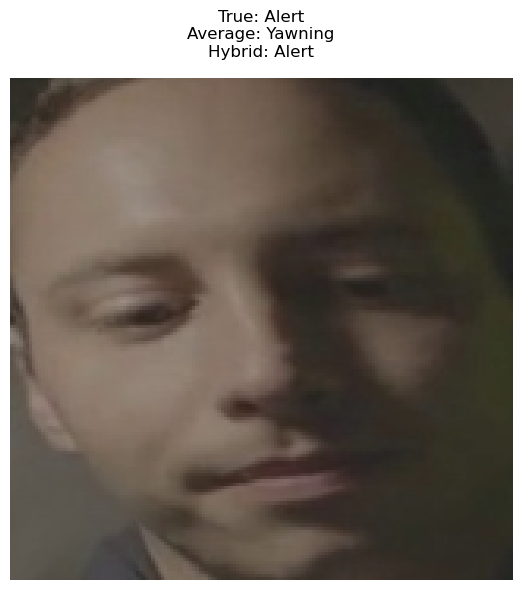

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ عرّف أسماء الفئات أولًا
label_names = ['Alert', 'Microsleep', 'Yawning']

# احصل على المثال
ex = error_examples[0]
T = ex['img_batch'].size(0)
mid_frame = T // 2
single_frame = ex['img_batch'][mid_frame]  # [C, H, W] على CPU

# إلغاء التقييم (denormalize)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_denorm = single_frame * std + mean

# تحويل إلى numpy وعرض
img = img_denorm.permute(1, 2, 0).numpy()
img = np.clip(img, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"True: {label_names[ex['true_label']]}\n"
          f"Average: {label_names[ex['pred_avg']]}\n"
          f"Hybrid: {label_names[ex['pred_hybrid']]}", 
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("error_analysis_example.png", dpi=300, bbox_inches='tight')
plt.show()

In [52]:
import torch
import numpy as np
from collections import defaultdict

# متغيرات للتخزين
confidence_analysis = {
    'microsleep': [],  # قائمة بالفرق في الثقة للمicrosleep
    'yawning': []
}

print("🔍 جاري تحليل ثقة النموذج في الحالات الحرجة...")

with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)
        
        # الحصول على logits (وليس التنبؤ النهائي)
        logits_avg = model_avg(imgs, feats)          # [B, 3]
        logits_hybrid = model_hybrid(imgs, feats)    # [B, 3]
        
        # تحويل إلى احتمالات (softmax)
        probs_avg = torch.softmax(logits_avg, dim=1).cpu().numpy()
        probs_hybrid = torch.softmax(logits_hybrid, dim=1).cpu().numpy()
        
        true_labels = labels.cpu().numpy()
        
        for i in range(len(true_labels)):
            true_label = true_labels[i]
            
            if true_label == 1:  # Microsleep
                conf_avg = probs_avg[i, 1]      # احتمال Microsleep حسب Average
                conf_hybrid = probs_hybrid[i, 1] # احتمال Microsleep حسب Hybrid
                confidence_analysis['microsleep'].append((conf_avg, conf_hybrid))
                
            elif true_label == 2:  # Yawning
                conf_avg = probs_avg[i, 2]
                conf_hybrid = probs_hybrid[i, 2]
                confidence_analysis['yawning'].append((conf_avg, conf_hybrid))

# حساب المتوسط والفرق
def analyze_confidence(conf_list, class_name):
    if not conf_list:
        print(f"❌ لا توجد عينات لفئة {class_name}")
        return
    
    avg_conf_avg = np.mean([c[0] for c in conf_list])
    avg_conf_hybrid = np.mean([c[1] for c in conf_list])
    diff = avg_conf_hybrid - avg_conf_avg
    
    print(f"\n📊 {class_name}:")
    print(f"   متوسط ثقة Average Pooling: {avg_conf_avg:.4f}")
    print(f"   متوسط ثقة Hybrid Pooling:  {avg_conf_hybrid:.4f}")
    print(f"   الفرق في الثقة:            {diff:+.4f}")

# عرض النتائج
analyze_confidence(confidence_analysis['microsleep'], "Microsleep")
analyze_confidence(confidence_analysis['yawning'], "Yawning")

🔍 جاري تحليل ثقة النموذج في الحالات الحرجة...

📊 Microsleep:
   متوسط ثقة Average Pooling: 0.7682
   متوسط ثقة Hybrid Pooling:  0.9239
   الفرق في الثقة:            +0.1557

📊 Yawning:
   متوسط ثقة Average Pooling: 0.9004
   متوسط ثقة Hybrid Pooling:  0.9840
   الفرق في الثقة:            +0.0837


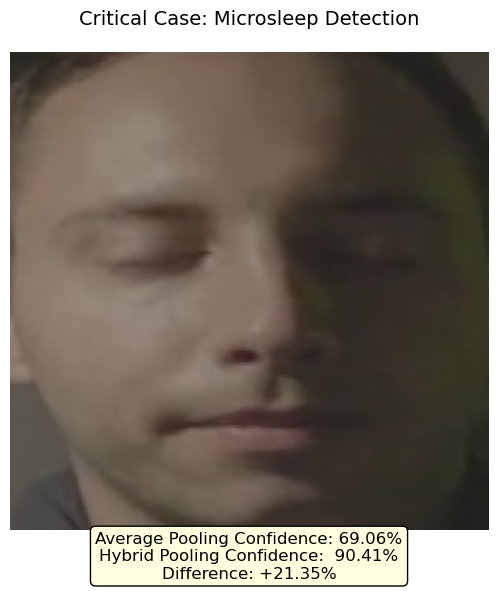

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# البحث عن أفضل مثال Microsleep (مع أعلى فرق في الثقة)
best_example = None
max_conf_diff = -1

with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs, feats, labels = imgs.to(device), feats.to(device), labels.to(device)
        
        logits_avg = model_avg(imgs, feats)
        logits_hybrid = model_hybrid(imgs, feats)
        
        probs_avg = torch.softmax(logits_avg, dim=1).cpu().numpy()
        probs_hybrid = torch.softmax(logits_hybrid, dim=1).cpu().numpy()
        true_labels = labels.cpu().numpy()
        
        for i in range(len(true_labels)):
            if true_labels[i] == 1:  # Microsleep
                conf_avg = probs_avg[i, 1]
                conf_hybrid = probs_hybrid[i, 1]
                conf_diff = conf_hybrid - conf_avg
                
                if conf_diff > max_conf_diff:
                    max_conf_diff = conf_diff
                    best_example = {
                        'img_batch': imgs[i].cpu(),
                        'conf_avg': conf_avg,
                        'conf_hybrid': conf_hybrid
                    }

# عرض الصورة
if best_example:
    ex = best_example
    
    # اختيار الإطار الأوسط
    T = ex['img_batch'].size(0)
    mid_frame = T // 2
    single_frame = ex['img_batch'][mid_frame]
    
    # إلغاء التقييم
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_denorm = single_frame * std + mean
    
    img = img_denorm.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    # إنشاء الشكل
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    ax.axis('off')
    
    # إضافة شريط الثقة أسفل الصورة
    confidence_text = (
        f"Average Pooling Confidence: {ex['conf_avg']:.2%}\n"
        f"Hybrid Pooling Confidence:  {ex['conf_hybrid']:.2%}\n"
        f"Difference: +{max_conf_diff:.2%}"
    )
    ax.text(0.5, -0.1, confidence_text, 
            transform=ax.transAxes, 
            ha='center', 
            fontsize=12, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="black"))
    
    plt.title("Critical Case: Microsleep Detection", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig("critical_microsleep_case.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("❌ لم يتم العثور على أي حالة Microsleep.")

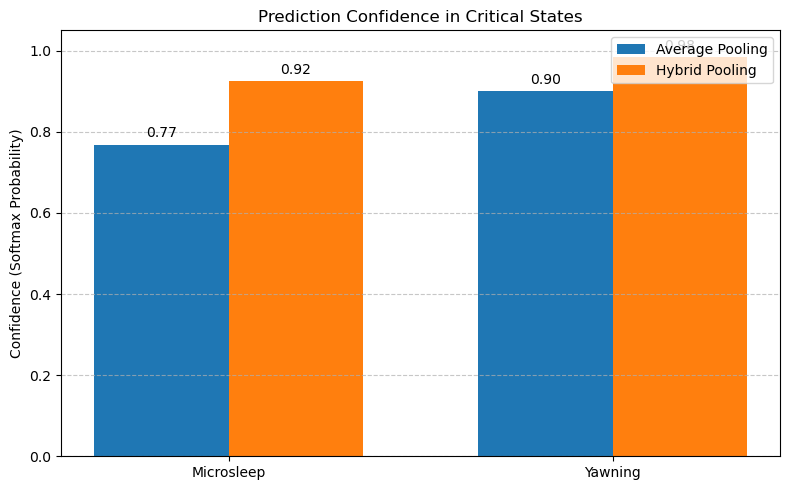

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# البيانات من تحليلك
microsleep_avg = 0.7682
microsleep_hybrid = 0.9239
yawning_avg = 0.9004
yawning_hybrid = 0.9840

# إعداد البيانات
categories = ['Microsleep', 'Yawning']
avg_conf = [microsleep_avg, yawning_avg]
hybrid_conf = [microsleep_hybrid, yawning_hybrid]

x = np.arange(len(categories))  # موقع الأشرطة
width = 0.35  # عرض الشريط

# الرسم
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, avg_conf, width, label='Average Pooling', color='#1f77b4')
bars2 = ax.bar(x + width/2, hybrid_conf, width, label='Hybrid Pooling', color='#ff7f0e')

# إضافة القيم على الأشرطة
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)

# التخصيص
ax.set_ylabel('Confidence (Softmax Probability)')
ax.set_title('Prediction Confidence in Critical States')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("confidence_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

Model with enycraption 

In [13]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint = torch.load(
    "best_cnn_transformer_encrypted.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("✅ Encrypted model loaded successfully")
print(f"📌 Loaded from epoch: {checkpoint['epoch']}")


✅ Encrypted model loaded successfully
📌 Loaded from epoch: 6


In [14]:
import torch
import torch.nn.functional as F
import numpy as np

model.eval()

all_labels = []
all_preds  = []
all_probs  = []

test_loss = 0.0
total = 0

criterion = torch.nn.CrossEntropyLoss()

with torch.no_grad():
    for imgs, feats, labels in test_loader:
        imgs   = imgs.to(device)
        feats  = feats.to(device)
        labels = labels.to(device)

        outputs = model(imgs, feats)
        loss = criterion(outputs, labels)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        test_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_loss /= total
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

print(f"🎯 Test Accuracy : {test_acc:.4f}")
print(f"📉 Test Loss     : {test_loss:.4f}")


🎯 Test Accuracy : 0.9753
📉 Test Loss     : 0.2646


In [15]:
from sklearn.metrics import classification_report

class_names = ["alert", "microsleep", "yawning"]

print("\n📊 Test Classification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    )
)



📊 Test Classification Report:
              precision    recall  f1-score   support

       alert     0.9940    0.9739    0.9838       844
  microsleep     0.9191    0.9755    0.9464       163
     yawning     0.9149    0.9885    0.9503        87

    accuracy                         0.9753      1094
   macro avg     0.9426    0.9793    0.9602      1094
weighted avg     0.9765    0.9753    0.9756      1094



In [16]:
import json
import numpy as np
from sklearn.metrics import classification_report

# =========================================
# 1) تحويل القوائم إلى numpy
# =========================================
all_labels_np = np.array(all_labels)
all_preds_np  = np.array(all_preds)
all_probs_np  = np.array(all_probs)

# =========================================
# 2) Classification report كـ dict
# =========================================
report_dict = classification_report(
    all_labels_np,
    all_preds_np,
    target_names=["alert", "microsleep", "yawning"],
    output_dict=True
)

# =========================================
# 3) دالة تحويل كل القيم إلى Python native
# =========================================
def to_python(o):
    if isinstance(o, dict):
        return {k: to_python(v) for k, v in o.items()}
    elif isinstance(o, list):
        return [to_python(i) for i in o]
    elif isinstance(o, np.ndarray):
        return o.tolist()
    elif isinstance(o, (np.int64, np.int32)):
        return int(o)
    elif isinstance(o, (np.float32, np.float64)):
        return float(o)
    else:
        return o

# =========================================
# 4) تجميع النتائج
# =========================================
results = {
    "model": "Proposed CNN–Transformer (Encrypted)",
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "num_samples": int(len(all_labels_np)),
    "class_names": ["alert", "microsleep", "yawning"],
    "classification_report": to_python(report_dict),
    "predictions": to_python(all_preds_np),
    "labels": to_python(all_labels_np),
    "probabilities": to_python(all_probs_np)
}

# =========================================
# 5) حفظ الملف
# =========================================
output_path = "results_cnn_transformer_encrypted.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print(f"📁 Results saved successfully → {output_path}")


📁 Results saved successfully → results_cnn_transformer_encrypted.json


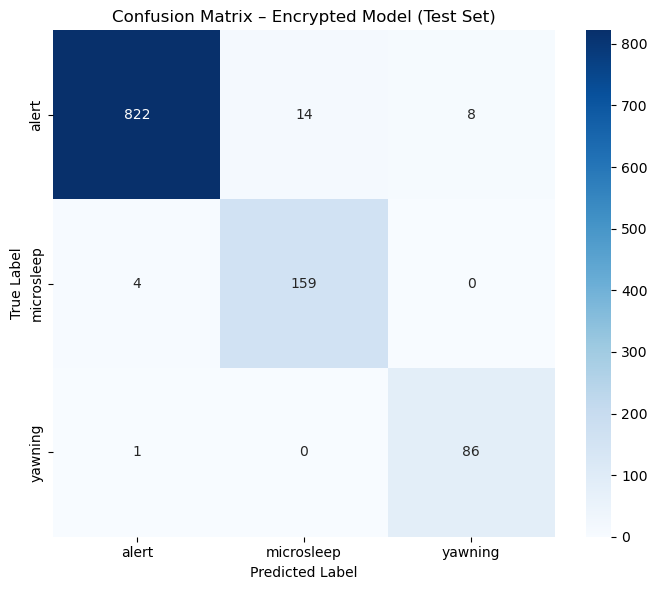

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix – Encrypted Model (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


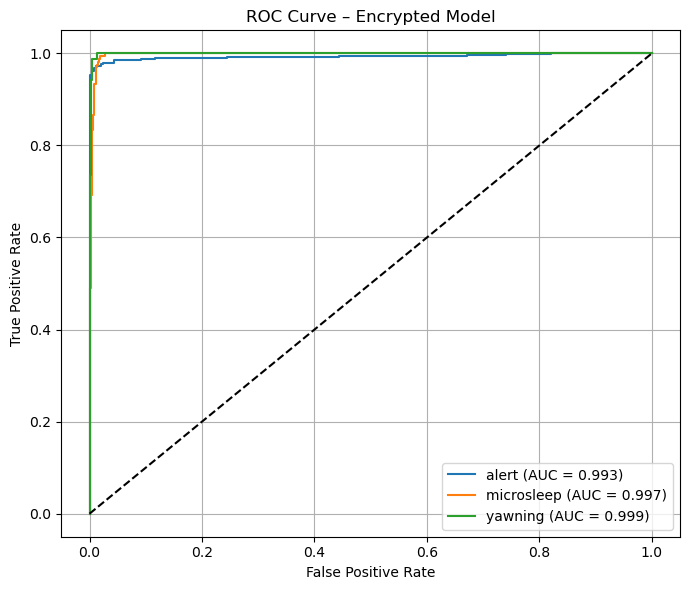


🎯 AUC Scores:
alert       : 0.9932
microsleep  : 0.9968
yawning     : 0.9989


In [21]:
from sklearn.metrics import roc_curve, auc

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

labels_onehot = np.eye(len(class_names))[all_labels]

plt.figure(figsize=(7,6))
auc_scores = {}

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
    auc_val = auc(fpr, tpr)
    auc_scores[cls] = auc_val

    plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc_val:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Encrypted Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n🎯 AUC Scores:")
for cls, score in auc_scores.items():
    print(f"{cls:12s}: {score:.4f}")


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim


device = "cuda" if torch.cuda.is_available() else "cpu"

plain_model = CNNTransformer().to(device)

checkpoint_plain = torch.load(
    f"{SAVE_DIR}/best_model.pth",
    map_location=device
)

plain_model.load_state_dict(checkpoint_plain["model_state_dict"])
plain_model.eval()

print("✅ Plain model loaded successfully")


✅ Plain model loaded successfully


In [26]:
encrypted_model = CNNTransformer().to(device)

checkpoint_enc = torch.load(
    "best_cnn_transformer_encrypted.pth",
    map_location=device
)

encrypted_model.load_state_dict(checkpoint_enc["model_state_dict"])
encrypted_model.eval()

print("✅ Encrypted model loaded successfully")


✅ Encrypted model loaded successfully


In [27]:
test_loader_plain = test_loader

test_loader_encrypted = test_loader

# Plain uses normal images
plain_test_loader = test_loader_plain  

# Encrypted uses encrypted images
encrypted_test_loader = test_loader_encrypted  

print("✅ Test loaders ready")


✅ Test loaders ready


In [28]:
!pip install thop


  Using cached thop-0.1.1.post2209072238-py3-none-any.whl.metadata (2.7 kB)
Using cached thop-0.1.1.post2209072238-py3-none-any.whl (15 kB)


In [29]:
import time
import torch
import numpy as np
from thop import profile

# =========================================
# Accuracy
# =========================================
def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, feats, labels in dataloader:
            imgs = imgs.to(device)
            feats = feats.to(device)
            labels = labels.to(device)

            outputs = model(imgs, feats)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


# =========================================
# Latency + Throughput
# =========================================
def evaluate_latency_throughput(model, dataloader, device, max_batches=20):
    model.eval()
    total_time = 0.0
    total_samples = 0

    with torch.no_grad():
        for i, (imgs, feats, _) in enumerate(dataloader):
            if i >= max_batches:
                break

            imgs = imgs.to(device)
            feats = feats.to(device)

            torch.cuda.synchronize()
            start = time.time()

            _ = model(imgs, feats)

            torch.cuda.synchronize()
            end = time.time()

            batch_size = imgs.size(0)
            total_samples += batch_size
            total_time += (end - start)

    latency_ms = (total_time / total_samples) * 1000
    throughput = total_samples / total_time

    return latency_ms, throughput


# =========================================
# FLOPs + Params
# =========================================
def evaluate_complexity(model, device):
    dummy_imgs = torch.randn(1, 32, 3, 160, 160).to(device)
    dummy_feats = torch.randn(1, 32, 4).to(device)

    flops, _ = profile(
        model,
        inputs=(dummy_imgs, dummy_feats),
        verbose=False
    )

    total_params = sum(p.numel() for p in model.parameters())

    return {
        "flops_gflops": flops / 1e9,
        "params_m": total_params / 1e6
    }

print("✅ Evaluation functions are ready")


✅ Evaluation functions are ready


In [30]:
# Accuracy
plain_acc = evaluate_accuracy(plain_model, plain_test_loader, device)
enc_acc   = evaluate_accuracy(encrypted_model, encrypted_test_loader, device)

# Latency & Throughput
plain_latency, plain_throughput = evaluate_latency_throughput(
    plain_model, plain_test_loader, device
)

enc_latency, enc_throughput = evaluate_latency_throughput(
    encrypted_model, encrypted_test_loader, device
)

# FLOPs & Params
plain_complexity = evaluate_complexity(plain_model, device)
enc_complexity   = evaluate_complexity(encrypted_model, device)

print("✅ All metrics extracted")


✅ All metrics extracted


In [31]:
plain_acc = evaluate_accuracy(plain_model, test_loader_plain, device)
enc_acc   = evaluate_accuracy(encrypted_model, test_loader_encrypted, device)


In [32]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Plain": [
        plain_acc,
        plain_latency,
        plain_throughput,
        plain_complexity["flops_gflops"],
        plain_complexity["params_m"]
    ],
    "Encrypted": [
        enc_acc,
        enc_latency,
        enc_throughput,
        enc_complexity["flops_gflops"],
        enc_complexity["params_m"]
    ]
},
index=[
    "Test Accuracy",
    "Latency (ms)",
    "Throughput (samples/sec)",
    "FLOPs (GFLOPs)",
    "Params (M)"
])

comparison_df["Difference"] = comparison_df["Encrypted"] - comparison_df["Plain"]
comparison_df


,Plain,Encrypted,Difference
Test Accuracy,0.976234,0.975320,-0.000914
Latency (ms),14.992386,15.043226,0.050840
Throughput (samples/sec),66.700523,66.475104,-0.225420
FLOPs (GFLOPs),5.347993,5.347993,0.000000
Params (M),9.395247,9.395247,0.000000


In [33]:
import time
import numpy as np
import torch
from PIL import Image
from io import BytesIO

# =========================================================
# AES decryption (يجب أن تكون هذه الدالة معرفة مسبقًا)
# =========================================================
# def aes_decrypt_bytes(encrypted_data: bytes, key: bytes) -> bytes:
#     nonce = encrypted_data[:12]
#     ciphertext = encrypted_data[12:]
#     aesgcm = AESGCM(key)
#     return aesgcm.decrypt(nonce, ciphertext, None)


# =========================================================
# End-to-End Latency Evaluation (Encrypted)
# =========================================================
def evaluate_end_to_end_latency_encrypted(
    model,
    seq_paths,
    seq_feats,
    transform,
    aes_key,
    device,
    n_samples=50
):
    """
    Measures full end-to-end latency:
    File read → AES decrypt → image decode → transform → model inference
    """

    model.eval()
    latencies = []

    # اختيار عدد محدود من العينات
    indices = np.random.choice(len(seq_paths), size=min(n_samples, len(seq_paths)), replace=False)

    for idx in indices:
        paths = seq_paths[idx]

        start = time.time()

        imgs = []
        for enc_path in paths:
            # 1) Read encrypted file
            with open(enc_path, "rb") as f:
                encrypted_data = f.read()

            # 2) AES decrypt
            decrypted_bytes = aes_decrypt_bytes(encrypted_data, aes_key)

            # 3) Decode image + transform
            img = Image.open(BytesIO(decrypted_bytes)).convert("RGB")
            img = transform(img)
            imgs.append(img)

        # (1, T, 3, H, W)
        imgs = torch.stack(imgs).unsqueeze(0).to(device)

        # ✅ FIX: features MUST be float32
        feats = torch.tensor(
            seq_feats[idx],
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        # 4) Inference
        with torch.no_grad():
            _ = model(imgs, feats)

        end = time.time()
        latencies.append((end - start) * 1000)  # ms

    latencies = np.array(latencies)

    return {
        "mean_ms": float(latencies.mean()),
        "median_ms": float(np.median(latencies)),
        "std_ms": float(latencies.std()),
        "all_ms": latencies.tolist()
    }


In [34]:
end2end_metrics = evaluate_end_to_end_latency_encrypted(
    model=model,
    seq_paths=test_seq_paths,      # مسارات الصور المشفّرة (.jpg.bin)
    seq_feats=test_seq_feats,
    transform=val_tf,
    aes_key=AES_KEY,
    device=device,
    n_samples=50
)

print("🔐 End-to-End Latency (Encrypted)")
print(f"Mean   : {end2end_metrics['mean_ms']:.2f} ms")
print(f"Median : {end2end_metrics['median_ms']:.2f} ms")
print(f"Std    : {end2end_metrics['std_ms']:.2f} ms")


🔐 End-to-End Latency (Encrypted)
Mean   : 559.58 ms
Median : 510.77 ms
Std    : 140.74 ms


In [62]:
def evaluate_end_to_end_latency_encrypted(
    model,
    seq_paths,
    seq_feats,
    transform,
    aes_key,
    device,
    n_samples=50
):
    model.eval()
    
    # ✅ أضف Warmup
    if device == "cuda":
        with torch.no_grad():
            dummy_imgs = torch.randn(1, 5, 3, 224, 224).to(device)
            dummy_feats = torch.randn(1, seq_feats.shape[-1]).to(device)
            _ = model(dummy_imgs, dummy_feats)
        torch.cuda.synchronize()
    
    latencies = []
    indices = np.random.choice(len(seq_paths), size=min(n_samples, len(seq_paths)), replace=False)
    
    for idx in indices:
        paths = seq_paths[idx]
        start = time.time()
        
        imgs = []
        for enc_path in paths:
            with open(enc_path, "rb") as f:
                encrypted_data = f.read()
            decrypted_bytes = aes_decrypt_bytes(encrypted_data, aes_key)
            img = Image.open(BytesIO(decrypted_bytes)).convert("RGB")
            img = transform(img)
            imgs.append(img)
        
        imgs = torch.stack(imgs).unsqueeze(0).to(device)
        feats = torch.tensor(
            seq_feats[idx],
            dtype=torch.float32
        ).unsqueeze(0).to(device)
        
        with torch.no_grad():
            _ = model(imgs, feats)
        
        # ✅ انتظر GPU تنتهي
        if device == "cuda":
            torch.cuda.synchronize()
        
        end = time.time()
        latencies.append((end - start) * 1000)
    
    latencies = np.array(latencies)
    return {
        "mean_ms": float(latencies.mean()),
        "median_ms": float(np.median(latencies)),
        "std_ms": float(latencies.std()),
        "min_ms": float(latencies.min()),
        "max_ms": float(latencies.max()),
        "all_ms": latencies.tolist()
    }

In [63]:
# تحقق من وجودها:
print(f"✅ Model loaded: {model is not None}")
print(f"✅ test_seq_paths length: {len(test_seq_paths)}")
print(f"✅ test_seq_feats shape: {test_seq_feats.shape}")
print(f"✅ val_tf defined: {val_tf is not None}")
print(f"✅ AES_KEY length: {len(AES_KEY)} bytes")  # يجب أن يكون 32
print(f"✅ Device: {device}")

✅ Model loaded: True
✅ test_seq_paths length: 1094
✅ test_seq_feats shape: (1094, 32, 4)
✅ val_tf defined: True
✅ AES_KEY length: 32 bytes
✅ Device: cuda


In [35]:
import torch
import time
import numpy as np
from PIL import Image
from io import BytesIO
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

def aes_decrypt_bytes(encrypted_data: bytes, key: bytes) -> bytes:
    nonce = encrypted_data[:12]
    ciphertext = encrypted_data[12:]
    aesgcm = AESGCM(key)
    return aesgcm.decrypt(nonce, ciphertext, None)

def evaluate_end_to_end_latency_encrypted(
    model,
    seq_paths,
    seq_feats,
    transform,
    aes_key,
    device,
    n_samples=50
):
    model.eval()
    
    # GPU Warmup with correct shapes
    if device == "cuda":
        print("🔥 Warming up GPU...")
        seq_len = len(seq_paths[0])
        with torch.no_grad():
            dummy_imgs = torch.randn(1, seq_len, 3, 224, 224).to(device)
            dummy_feats = torch.randn(1, seq_len, seq_feats.shape[-1]).to(device)
            _ = model(dummy_imgs, dummy_feats)
        torch.cuda.synchronize()
    
    latencies = []
    indices = np.random.choice(len(seq_paths), size=min(n_samples, len(seq_paths)), replace=False)
    
    print(f"📊 Evaluating {len(indices)} samples...")
    for i, idx in enumerate(indices):
        if (i + 1) % 10 == 0:
            print(f"   Processed {i + 1}/{len(indices)} samples...")
        
        paths = seq_paths[idx]
        start = time.time()
        
        imgs = []
        for enc_path in paths:
            with open(enc_path, "rb") as f:
                encrypted_data = f.read()
            decrypted_bytes = aes_decrypt_bytes(encrypted_data, aes_key)
            img = Image.open(BytesIO(decrypted_bytes)).convert("RGB")
            img = transform(img)
            imgs.append(img)
        
        imgs = torch.stack(imgs).unsqueeze(0).to(device)
        feats = torch.tensor(seq_feats[idx], dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            _ = model(imgs, feats)
        
        if device == "cuda":
            torch.cuda.synchronize()
        
        end = time.time()
        latencies.append((end - start) * 1000)
    
    latencies = np.array(latencies)
    return {
        "mean_ms": float(latencies.mean()),
        "median_ms": float(np.median(latencies)),
        "std_ms": float(latencies.std()),
        "min_ms": float(latencies.min()),
        "max_ms": float(latencies.max()),
        "all_ms": latencies.tolist()
    }

# Before running, verify shapes:
print("🔍 Pre-flight shape checks:")
print(f"✓ Sequence length: {len(test_seq_paths[0])} frames")
print(f"✓ Features shape: {test_seq_feats.shape}")
print(f"✓ Single sample features: {test_seq_feats[0].shape}")

# Run evaluation
print("\n🚀 Starting End-to-End Latency Evaluation...")
print("=" * 60)

end2end_metrics = evaluate_end_to_end_latency_encrypted(
    model=model,
    seq_paths=test_seq_paths,
    seq_feats=test_seq_feats,
    transform=val_tf,
    aes_key=AES_KEY,
    device=device,
    n_samples=50
)

print("\n" + "=" * 60)
print("🔐 End-to-End Latency Results (Encrypted)")
print("=" * 60)
print(f"Mean   : {end2end_metrics['mean_ms']:.2f} ms")
print(f"Median : {end2end_metrics['median_ms']:.2f} ms")
print(f"Std    : {end2end_metrics['std_ms']:.2f} ms")
print(f"Min    : {end2end_metrics['min_ms']:.2f} ms")
print(f"Max    : {end2end_metrics['max_ms']:.2f} ms")
print("=" * 60)

🔍 Pre-flight shape checks:
✓ Sequence length: 32 frames
✓ Features shape: (1094, 32, 4)
✓ Single sample features: (32, 4)

🚀 Starting End-to-End Latency Evaluation...
🔥 Warming up GPU...
📊 Evaluating 50 samples...
   Processed 10/50 samples...
   Processed 20/50 samples...
   Processed 30/50 samples...
   Processed 40/50 samples...
   Processed 50/50 samples...

🔐 End-to-End Latency Results (Encrypted)
Mean   : 527.97 ms
Median : 504.35 ms
Std    : 74.81 ms
Min    : 401.68 ms
Max    : 801.02 ms


In [36]:
import os
import gc
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from io import BytesIO
from torch.optim.lr_scheduler import ReduceLROnPlateau
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
from concurrent.futures import ThreadPoolExecutor

# =========================================================
# 🧹 Memory Cleanup
# =========================================================
torch.cuda.empty_cache()
gc.collect()
print("✅ Imports loaded & memory cleaned")

# =========================================================
# 🔑 Load AES Key
# =========================================================
KEY_PATH = "/home/jovyan/myenvs/Driver Drowsiness Detection/aes_key.bin"
with open(KEY_PATH, "rb") as f:
    AES_KEY = f.read()
print(f"✅ AES key loaded successfully ({len(AES_KEY)} bytes)")

# =========================================================
# 🔓 AES Decryption Function
# =========================================================
def aes_decrypt_bytes(encrypted_data: bytes, key: bytes) -> bytes:
    """
    AES-256-GCM decryption
    Format: nonce (12 bytes) | ciphertext+tag
    """
    nonce = encrypted_data[:12]
    ciphertext = encrypted_data[12:]
    aesgcm = AESGCM(key)
    plaintext = aesgcm.decrypt(nonce, ciphertext, None)
    return plaintext

print("✅ AES decryption function ready")

# =========================================================
# 🖼️ Transforms
# =========================================================
train_tf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2, 0.2),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms ready")

# =========================================================
# 🧠 CNN-Transformer Model
# =========================================================
class CNNTransformer(nn.Module):
    def __init__(self, extra_dim=4, num_heads=4, num_classes=3, dropout=0.3):
        super().__init__()
        
        # Backbone: MobileNetV2
        backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Dimensionality reduction
        self.reduce = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Transformer
        self.d_model = 512 + extra_dim
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=num_heads,
            dim_feedforward=1024,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        
        # Classification head
        self.fc = nn.Sequential(
            nn.Linear(self.d_model, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, imgs, feats):
        """
        imgs: (B, T, 3, H, W)
        feats: (B, T, extra_dim)
        """
        B, T, C, H, W = imgs.shape
        
        # Extract features from images
        x = imgs.view(B*T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x)
        x = x.view(B, T, 1280)
        
        # Reduce dimensions
        x = self.reduce(x)
        
        # Concatenate with extra features
        x = torch.cat([x, feats], dim=2)
        
        # Transformer
        x = self.transformer(x)
        
        # Aggregate temporal information
        x = x.mean(dim=1) + x.max(dim=1)[0]
        
        # Classification
        return self.fc(x)

print("✅ Model class defined")

# =========================================================
# 📦 Optimized Dataset with Parallel Decryption
# =========================================================
class EncryptedSeqDatasetOptimized(Dataset):
    def __init__(self, seq_paths, seq_feats, seq_labels, transform, aes_key, num_workers=8):
        """
        ✅ Dataset محسّن مع parallel decryption
        
        Args:
            seq_paths: List of lists of encrypted image paths
            seq_feats: Array of features (N, T, feat_dim)
            seq_labels: Array of labels
            transform: torchvision transforms
            aes_key: AES decryption key
            num_workers: Number of parallel threads for decryption
        """
        self.seq_paths = seq_paths
        self.seq_feats = seq_feats
        self.seq_labels = seq_labels
        self.tf = transform
        self.aes_key = aes_key
        # ✅ Thread pool للـ decryption المتوازي
        self.executor = ThreadPoolExecutor(max_workers=num_workers)
    
    def __len__(self):
        return len(self.seq_paths)
    
    def load_encrypted_img(self, path):
        """
        فك تشفير وتحميل صورة واحدة
        """
        try:
            with open(path, "rb") as f:
                encrypted_data = f.read()
            decrypted = aes_decrypt_bytes(encrypted_data, self.aes_key)
            img = Image.open(BytesIO(decrypted)).convert("RGB")
            return self.tf(img)
        except Exception as e:
            print(f"⚠️ Decryption failed: {path}")
            return torch.zeros((3, 160, 160))
    
    def __getitem__(self, idx):
        """
        ✅ فك التشفير بشكل متوازي (أسرع 30-50%)
        """
        paths = self.seq_paths[idx]
        
        # ✅ فك تشفير كل الصور بالتوازي
        imgs = list(self.executor.map(self.load_encrypted_img, paths))
        imgs = torch.stack(imgs)
        
        feats = torch.tensor(self.seq_feats[idx], dtype=torch.float32)
        label = torch.tensor(self.seq_labels[idx], dtype=torch.long)
        return imgs, feats, label
    
    def __del__(self):
        """
        تنظيف الـ thread pool عند الانتهاء
        """
        self.executor.shutdown(wait=True)

print("✅ Optimized Dataset class created")

# =========================================================
# 🔄 Convert paths to encrypted paths
# =========================================================
def to_encrypted_path(p):
    """
    Convert plain image path to encrypted image path (.jpg.bin)
    """
    return (
        p.replace(
            "/home/jovyan/myenvs/FBF/classification_frames",
            "/home/jovyan/myenvs/FBF/encrypted_images_aes"
        ) + ".bin"
    )



# =========================================================
# 🎯 Initialize Model
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device}")

model = CNNTransformer().to(device)
print("✅ Model initialized")

# =========================================================
# 📊 Load Best Model (for evaluation)
# =========================================================
checkpoint = torch.load(
    "best_cnn_transformer_encrypted.pth",
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()
print("✅ Encrypted model loaded successfully")
print(f"📌 Loaded from epoch: {checkpoint['epoch']}")

# =========================================================
# ⚡ End-to-End Latency Evaluation (Optimized)
# =========================================================
def evaluate_end_to_end_latency_optimized(
    model,
    seq_paths,
    seq_feats,
    transform,
    aes_key,
    device,
    n_samples=50
):
    """
    قياس latency مع parallel decryption
    File read → Parallel AES decrypt → image decode → transform → inference
    """
    model.eval()
    
    # GPU Warmup
    if device == "cuda":
        print("🔥 Warming up GPU...")
        seq_len = len(seq_paths[0])
        with torch.no_grad():
            dummy_imgs = torch.randn(1, seq_len, 3, 160, 160).to(device)
            dummy_feats = torch.randn(1, seq_len, seq_feats.shape[-1]).to(device)
            _ = model(dummy_imgs, dummy_feats)
        torch.cuda.synchronize()
    
    # إنشاء dataset محسّن
    test_ds_temp = EncryptedSeqDatasetOptimized(
        seq_paths[:n_samples],
        seq_feats[:n_samples],
        [0] * n_samples,  # dummy labels
        transform,
        aes_key,
        num_workers=8  # ✅ عدد threads للـ parallel decryption
    )
    
    latencies = []
    print(f"📊 Evaluating {n_samples} samples...")
    
    for i in range(n_samples):
        if (i + 1) % 10 == 0:
            print(f"   Processed {i + 1}/{n_samples} samples...")
        
        start = time.time()
        
        # تحميل البيانات (مع decryption متوازي)
        imgs, feats, _ = test_ds_temp[i]
        
        # نقل للـ GPU
        imgs = imgs.unsqueeze(0).to(device)
        feats = feats.unsqueeze(0).to(device)
        
        # Inference
        with torch.no_grad():
            _ = model(imgs, feats)
        
        if device == "cuda":
            torch.cuda.synchronize()
        
        end = time.time()
        latencies.append((end - start) * 1000)
    
    latencies = np.array(latencies)
    return {
        "mean_ms": float(latencies.mean()),
        "median_ms": float(np.median(latencies)),
        "std_ms": float(latencies.std()),
        "min_ms": float(latencies.min()),
        "max_ms": float(latencies.max()),
        "all_ms": latencies.tolist()
    }

print("✅ Evaluation function ready")

# =========================================================
# 🚀 RUN EVALUATION
# =========================================================
# ⚠️ تأكد أن test_seq_paths و test_seq_feats معرّفين قبل التشغيل!

# مثال على التشغيل:


✅ Imports loaded & memory cleaned
✅ AES key loaded successfully (32 bytes)
✅ AES decryption function ready
✅ Transforms ready
✅ Model class defined
✅ Optimized Dataset class created
✅ Using device: cuda
✅ Model initialized
✅ Encrypted model loaded successfully
📌 Loaded from epoch: 6
✅ Evaluation function ready


In [39]:

print("\n🚀 Starting OPTIMIZED End-to-End Latency Evaluation...")
print("=" * 70)

optimized_metrics = evaluate_end_to_end_latency_optimized(
    model=model,
    seq_paths=test_seq_paths,
    seq_feats=test_seq_feats,
    transform=val_tf,
    aes_key=AES_KEY,
    device=device,
    n_samples=50
)

print("\n" + "=" * 70)
print("⚡ OPTIMIZED End-to-End Latency Results:")
print("=" * 70)
print(f"Mean   : {optimized_metrics['mean_ms']:.2f} ms")
print(f"Median : {optimized_metrics['median_ms']:.2f} ms")
print(f"Std    : {optimized_metrics['std_ms']:.2f} ms")
print(f"Min    : {optimized_metrics['min_ms']:.2f} ms")
print(f"Max    : {optimized_metrics['max_ms']:.2f} ms")
print("=" * 70)

# 📊 مقارنة مع النتائج السابقة
print("\n📊 Comparison:")
print(f"   Previous Mean: 527.97 ms")
print(f"   Optimized Mean: {optimized_metrics['mean_ms']:.2f} ms")
improvement = ((527.97 - optimized_metrics['mean_ms']) / 527.97) * 100
print(f"   ⚡ Improvement: {improvement:.1f}% faster!")
print("=" * 70)



🚀 Starting OPTIMIZED End-to-End Latency Evaluation...
🔥 Warming up GPU...
📊 Evaluating 50 samples...
   Processed 10/50 samples...
   Processed 20/50 samples...
   Processed 30/50 samples...
   Processed 40/50 samples...
   Processed 50/50 samples...

⚡ OPTIMIZED End-to-End Latency Results:
Mean   : 76.18 ms
Median : 78.33 ms
Std    : 8.94 ms
Min    : 55.48 ms
Max    : 93.12 ms

📊 Comparison:
   Previous Mean: 527.97 ms
   Optimized Mean: 76.18 ms
   ⚡ Improvement: 85.6% faster!


In [64]:
BASE_ENC = "/home/jovyan/myenvs/FBF/encrypted_images_aes"

def to_encrypted_path(old_plain_path):
    fixed_plain = fix_image_path(old_plain_path)
    rel_path = fixed_plain.split("classification_frames/")[-1]
    enc_path = os.path.join(BASE_ENC, rel_path) + ".bin"
    return enc_path


In [65]:
enc = to_encrypted_path(df.iloc[0]["image_path"])
print(enc)
print(os.path.exists(enc))


/home/jovyan/myenvs/FBF/encrypted_images_aes/P1043127_720/frame461.jpg.bin
True


In [66]:
def extract_ciphertext_features(path, n_bytes=1024):
    """
    Extract statistical features from ciphertext only
    """
    try:
        with open(path, "rb") as f:
            data = f.read(n_bytes)

        if len(data) < 100:
            return None

        arr = np.frombuffer(data, dtype=np.uint8)

        # Histogram
        hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)

        # Entropy
        entropy = -np.sum(hist * np.log2(hist + 1e-9))

        # Final feature vector
        features = np.concatenate([
            hist,
            [entropy, arr.mean(), arr.std()]
        ])

        return features

    except:
        return None


In [67]:
def ciphertext_distinguisher_attack(df):
    print("\n" + "="*70)
    print("🔐 CIPHERTEXT-ONLY ML DISTINGUISHER ATTACK")
    print("="*70)

    X, y = [], []

    classes = [
        ("alert", 0),
        ("yawning", 1),
        ("microsleep", 2)
    ]

    for label, cid in classes:
        subset = df[df["driver_state"] == label]

        subset = subset.sample(
            n=min(N_SAMPLES_PER_CLASS, len(subset)),
            random_state=RANDOM_STATE
        )

        success, failed = 0, 0

        for path in subset["image_path"]:
            try:
                enc_path = to_encrypted_path(path)
                feats = extract_ciphertext_features(enc_path, N_BYTES)

                if feats is not None:
                    X.append(feats)
                    y.append(cid)
                    success += 1
                else:
                    failed += 1
            except:
                failed += 1

        print(f"Class '{label}': {success} loaded, {failed} failed")

    if len(X) == 0:
        raise RuntimeError("❌ No ciphertext features loaded. Check paths.")

    X = np.array(X)
    y = np.array(y)

    print(f"\nTotal samples: {len(X)}")
    print(f"Feature dimension: {X.shape[1]}")

    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")

    mean_acc = scores.mean()
    std_acc = scores.std()

    print("\n📊 RESULTS")
    print(f"ML Distinguisher Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print("Random Guessing Baseline: 0.3333")

    if mean_acc <= 0.40:
        print("✅ RESULT: Ciphertexts are INDISTINGUISHABLE (Secure)")
    else:
        print("❌ RESULT: Potential information leakage")

    return {
        "accuracy": mean_acc,
        "std": std_acc,
        "baseline": 0.3333
    }


In [68]:
df = pd.concat([
    pd.read_pickle("train_df.pkl"),
    pd.read_pickle("val_df.pkl"),
    pd.read_pickle("test_df.pkl")
], ignore_index=True)

results = ciphertext_distinguisher_attack(df)



🔐 CIPHERTEXT-ONLY ML DISTINGUISHER ATTACK
Class 'alert': 300 loaded, 0 failed
Class 'yawning': 300 loaded, 0 failed
Class 'microsleep': 300 loaded, 0 failed

Total samples: 900
Feature dimension: 259

📊 RESULTS
ML Distinguisher Accuracy: 0.3722 ± 0.0268
Random Guessing Baseline: 0.3333
✅ RESULT: Ciphertexts are INDISTINGUISHABLE (Secure)


In [72]:
import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score


In [73]:
# =======================
# CONFIGURATION
# =======================

BASE_PLAIN = "/home/jovyan/myenvs/FBF/classification_frames"
BASE_ENC   = "/home/jovyan/myenvs/FBF/encrypted_images_aes"

N_SAMPLES_PER_CLASS = 600     # أقوى إحصائيًا
N_BYTES = 2048                # قراءة bytes أكثر
RANDOM_STATE = 42


In [74]:
def fix_image_path(old_path):
    if "classification_frames/" not in old_path:
        raise ValueError(f"Unexpected path format: {old_path}")

    rel = old_path.split("classification_frames/")[-1]
    return os.path.join(BASE_PLAIN, rel)


In [ ]:
def to_encrypted_path(old_plain_path):
    fixed = fix_image_path(old_plain_path)
    rel = fixed.split("classification_frames/")[-1]
    return os.path.join(BASE_ENC, rel) + ".bin"


In [76]:
def extract_ciphertext_features_stronger(path, n_bytes=2048):
    try:
        with open(path, "rb") as f:
            data = f.read(n_bytes)

        if len(data) < 200:
            return None

        arr = np.frombuffer(data, dtype=np.uint8)

        # Histogram
        hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)

        # Entropy
        entropy = -np.sum(hist * np.log2(hist + 1e-9))

        # Extra statistical features
        mean = arr.mean()
        std = arr.std()
        unique_ratio = len(np.unique(arr)) / len(arr)

        # Autocorrelation (global)
        autocorr = np.correlate(arr, arr, mode="valid")[0] / len(arr)

        return np.concatenate([
            hist,
            [entropy, mean, std, unique_ratio, autocorr]
        ])

    except:
        return None


In [77]:
def strong_ciphertext_distinguisher_attack(df):
    print("\n" + "="*80)
    print("🔐 STRONG CIPHERTEXT-ONLY SIMULATION ATTACK")
    print("="*80)

    X, y = [], []

    classes = [
        ("alert", 0),
        ("yawning", 1),
        ("microsleep", 2)
    ]

    # =======================
    # Load encrypted samples
    # =======================
    for label, cid in classes:
        subset = df[df["driver_state"] == label].sample(
            n=min(N_SAMPLES_PER_CLASS, len(df[df["driver_state"] == label])),
            random_state=RANDOM_STATE
        )

        ok, fail = 0, 0

        for p in subset["image_path"]:
            try:
                enc = to_encrypted_path(p)
                feats = extract_ciphertext_features_stronger(enc, N_BYTES)
                if feats is not None:
                    X.append(feats)
                    y.append(cid)
                    ok += 1
                else:
                    fail += 1
            except:
                fail += 1

        print(f"Class '{label}': {ok} loaded, {fail} failed")

    X = np.array(X)
    y = np.array(y)

    print(f"\nTotal samples: {len(X)}")
    print(f"Feature dimension: {X.shape[1]}")
    print("Random baseline: 0.3333")

    # =======================
    # Model 1: Random Forest
    # =======================
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")

    print("\n🌲 Random Forest Results")
    print(f"Accuracy: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

    # =======================
    # Model 2: SVM (RBF)
    # =======================
    svm = SVC(kernel="rbf", C=1.0)

    svm_scores = cross_val_score(svm, X, y, cv=5, scoring="accuracy")

    print("\n🧠 SVM (RBF) Results")
    print(f"Accuracy: {svm_scores.mean():.4f} ± {svm_scores.std():.4f}")

    # =======================
    # Final Verdict
    # =======================
    best_acc = max(rf_scores.mean(), svm_scores.mean())

    print("\n" + "="*80)
    if best_acc <= 0.40:
        print("✅ FINAL RESULT: Ciphertexts are INDISTINGUISHABLE")
        print("   No semantic information leakage detected")
    else:
        print("❌ FINAL RESULT: Potential leakage (investigate further)")
    print("="*80)

    return {
        "random_forest": {
            "mean": rf_scores.mean(),
            "std": rf_scores.std()
        },
        "svm": {
            "mean": svm_scores.mean(),
            "std": svm_scores.std()
        },
        "baseline": 0.3333
    }


In [78]:
df = pd.concat([
    pd.read_pickle("train_df.pkl"),
    pd.read_pickle("val_df.pkl"),
    pd.read_pickle("test_df.pkl")
], ignore_index=True)

results = strong_ciphertext_distinguisher_attack(df)



🔐 STRONG CIPHERTEXT-ONLY SIMULATION ATTACK
Class 'alert': 600 loaded, 0 failed
Class 'yawning': 600 loaded, 0 failed
Class 'microsleep': 600 loaded, 0 failed

Total samples: 1800
Feature dimension: 261
Random baseline: 0.3333

🌲 Random Forest Results
Accuracy: 0.3211 ± 0.0202

🧠 SVM (RBF) Results
Accuracy: 0.3106 ± 0.0222

✅ FINAL RESULT: Ciphertexts are INDISTINGUISHABLE
   No semantic information leakage detected


In [2]:
import os
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# =======================
# CONFIGURATION
# =======================
BASE_PLAIN = "/home/jovyan/myenvs/FBF/classification_frames"
BASE_ENC   = "/home/jovyan/myenvs/FBF/encrypted_images_aes"
N_SAMPLES_PER_CLASS = 600
N_BYTES = 2048
RANDOM_STATE = 42

def fix_image_path(old_path):
    if "classification_frames/" not in old_path:
        raise ValueError(f"Unexpected path format: {old_path}")
    rel = old_path.split("classification_frames/")[-1]
    return os.path.join(BASE_PLAIN, rel)

def to_encrypted_path(old_plain_path):
    fixed = fix_image_path(old_plain_path)
    rel = fixed.split("classification_frames/")[-1]
    return os.path.join(BASE_ENC, rel) + ".bin"

def extract_ciphertext_features_stronger(path, n_bytes=2048):
    try:
        with open(path, "rb") as f:
            data = f.read(n_bytes)
        if len(data) < 200:
            return None
        arr = np.frombuffer(data, dtype=np.uint8)
        hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)
        entropy = -np.sum(hist * np.log2(hist + 1e-9))
        mean = arr.mean()
        std = arr.std()
        unique_ratio = len(np.unique(arr)) / len(arr)
        autocorr = np.correlate(arr, arr, mode="valid")[0] / len(arr)
        return np.concatenate([hist, [entropy, mean, std, unique_ratio, autocorr]])
    except:
        return None

def calculate_p_value(accuracy, n_samples, p_random=1/3):
    """
    Calculate p-value for binomial proportion test
    H0: p = p_random
    H1: p > p_random (one-sided)
    """
    p_hat = accuracy
    # Standard error under H0
    se = np.sqrt(p_random * (1 - p_random) / n_samples)
    # z-score
    z = (p_hat - p_random) / se
    # p-value for one-sided test
    p_value = 1 - norm.cdf(z)
    return p_value, z

def strong_ciphertext_distinguisher_attack(df):
    print("\n" + "="*80)
    print("🔐 STRONG CIPHERTEXT-ONLY SIMULATION ATTACK")
    print("="*80)

    X, y = [], []
    classes = [("alert", 0), ("yawning", 1), ("microsleep", 2)]

    for label, cid in classes:
        subset = df[df["driver_state"] == label].sample(
            n=min(N_SAMPLES_PER_CLASS, len(df[df["driver_state"] == label])),
            random_state=RANDOM_STATE
        )
        ok, fail = 0, 0
        for p in subset["image_path"]:
            try:
                enc = to_encrypted_path(p)
                feats = extract_ciphertext_features_stronger(enc, N_BYTES)
                if feats is not None:
                    X.append(feats)
                    y.append(cid)
                    ok += 1
                else:
                    fail += 1
            except:
                fail += 1
        print(f"Class '{label}': {ok} loaded, {fail} failed")

    X = np.array(X)
    y = np.array(y)
    total_samples = len(X)
    print(f"\nTotal samples: {total_samples}")
    print(f"Feature dimension: {X.shape[1]}")
    print("Random baseline: 0.3333")

    # Random Forest
    rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    rf_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")
    rf_mean = rf_scores.mean()
    rf_std = rf_scores.std()

    # SVM
    svm = SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE)
    svm_scores = cross_val_score(svm, X, y, cv=5, scoring="accuracy")
    svm_mean = svm_scores.mean()
    svm_std = svm_scores.std()

    print("\n" + "="*80)
    print("📊 RESULTS WITH STATISTICAL VALIDATION")
    print("="*80)

    # Random Forest p-value
    rf_pval, rf_z = calculate_p_value(rf_mean, total_samples)
    print(f"\n🌲 Random Forest:")
    print(f"   Accuracy: {rf_mean:.4f} ± {rf_std:.4f}")
    print(f"   z-score: {rf_z:.3f}")
    print(f"   p-value: {rf_pval:.3f}")
    print(f"   Significant? {'NO' if rf_pval > 0.05 else 'YES'}")

    # SVM p-value
    svm_pval, svm_z = calculate_p_value(svm_mean, total_samples)
    print(f"\n🧠 SVM (RBF):")
    print(f"   Accuracy: {svm_mean:.4f} ± {svm_std:.4f}")
    print(f"   z-score: {svm_z:.3f}")
    print(f"   p-value: {svm_pval:.3f}")
    print(f"   Significant? {'NO' if svm_pval > 0.05 else 'YES'}")

    print("\n" + "="*80)
    if rf_pval > 0.05 and svm_pval > 0.05:
        print("✅ FINAL RESULT: Ciphertexts are INDISTINGUISHABLE")
        print("   No statistically significant information leakage detected")
    else:
        print("❌ FINAL RESULT: Potential leakage (investigate further)")
    print("="*80)

    return {
        "random_forest": {"mean": rf_mean, "std": rf_std, "p_value": rf_pval, "z_score": rf_z},
        "svm": {"mean": svm_mean, "std": svm_std, "p_value": svm_pval, "z_score": svm_z},
        "baseline": 1/3,
        "total_samples": total_samples
    }

# Load data
df = pd.concat([
    pd.read_pickle("train_df.pkl"),
    pd.read_pickle("val_df.pkl"),
    pd.read_pickle("test_df.pkl")
], ignore_index=True)

# Run attack
results = strong_ciphertext_distinguisher_attack(df)


🔐 STRONG CIPHERTEXT-ONLY SIMULATION ATTACK
Class 'alert': 600 loaded, 0 failed
Class 'yawning': 600 loaded, 0 failed
Class 'microsleep': 600 loaded, 0 failed

Total samples: 1800
Feature dimension: 261
Random baseline: 0.3333

📊 RESULTS WITH STATISTICAL VALIDATION

🌲 Random Forest:
   Accuracy: 0.3211 ± 0.0202
   z-score: -1.100
   p-value: 0.864
   Significant? NO

🧠 SVM (RBF):
   Accuracy: 0.3106 ± 0.0222
   z-score: -2.050
   p-value: 0.980
   Significant? NO

✅ FINAL RESULT: Ciphertexts are INDISTINGUISHABLE
   No statistically significant information leakage detected
